In [1]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 88.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files

In [4]:
import os
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import ParameterSampler

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Circle, FancyArrowPatch

import torch
import torch.nn.functional as F
from torch import nn
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, BatchNorm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

In [5]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig
from torch_geometric.utils import to_networkx

## Functions to read the file and plot the code

In [6]:
# =========================================================
# Paths
# =========================================================
BASE_PATH = "/content/drive/My Drive/Colab Notebooks/Seg_Curves/"
TEST_DIR = os.path.join(BASE_PATH, "Test")
TRAIN_DIR = os.path.join(BASE_PATH, "Train")

CURVE_TYPES = [8, 9, 10, 11, 12, 13, 14, 15]

In [7]:
# =========================================================
# Helper function to load and combine Excel files
# =========================================================
def load_and_concat_files(curve_types, folder, file_prefix, category = "params"):
    dfs = []

    for n_points in curve_types:
        if category == "params":
            file_path = os.path.join(folder, f"{file_prefix}_{n_points}points.xlsx")
        else:
            file_path = os.path.join(folder, f"{file_prefix}_{n_points}points_shuffled.xlsx")


        if os.path.exists(file_path):
            df = pd.read_excel(file_path, engine="openpyxl")

            df["n_points"] = n_points
            df["source_file"] = os.path.basename(file_path)
            dfs.append(df)
        else:
            print(f"[SKIP] File not found: {file_path}")

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame()

In [8]:
# =========================================================
# Create the 4 big dataframes
# =========================================================
df_points_train = load_and_concat_files(CURVE_TYPES, TRAIN_DIR, "ACi_points", category = "points")
df_params_train = load_and_concat_files(CURVE_TYPES, TRAIN_DIR, "ACi_params")

df_points = load_and_concat_files(CURVE_TYPES, TEST_DIR, "ACi_points", category = "points")
df_params = load_and_concat_files(CURVE_TYPES, TEST_DIR, "ACi_params")

# =========================================================
# Optional check
# =========================================================
print("All points train dataframe shape :", df_points_train.shape)
print("All params train dataframe shape :", df_params_train.shape)
print("All points dataframe shape :", df_points.shape)
print("All params dataframe shape :", df_params.shape)

All points train dataframe shape : (97987, 7)
All params train dataframe shape : (8458, 9)
All points dataframe shape : (24528, 7)
All params dataframe shape : (2117, 9)


## Add noise to data

In [9]:
df_points = df_points.set_index("curve_id")
df_params = df_params.set_index("curve_id")
df_points_train = df_points_train.set_index("curve_id")
df_params_train = df_params_train.set_index("curve_id")

df_points_N = df_points.copy()              #add_noise(df_points,pct_noise)
df_points_train_N = df_points_train.copy()  #add_noise(df_points_train,pct_noise)

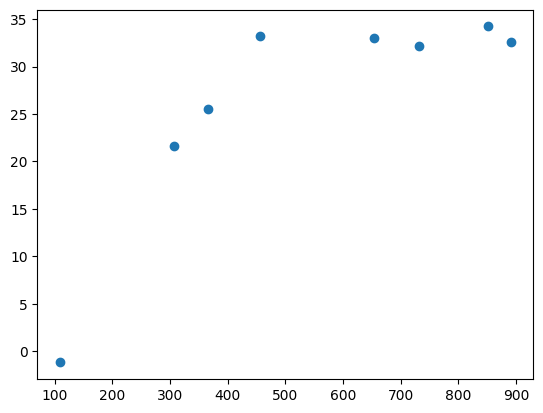

In [10]:
curve_id = 101
plt.scatter(df_points_N.loc[curve_id]['Ci'],df_points_N.loc[curve_id]['Anet'])
plt.show()

## Add edge feature

In [11]:
# =======================
#  Add edge conenction
# =======================
def compute_edge_Ac_Aj(
    Ci,
    Anet,
    Tleaf_c: float):

    Pa = 101.325   # [kPa]
    O2 = 210.0     # [mmol mol-1]

    Ci = np.asarray(Ci, dtype=float)
    Anet = np.asarray(Anet, dtype=float)

    R = 8.314 / 1000.0  # kJ mol-1 K-1

    Ko = 1000.0/Pa * np.exp(12.3772 - 23720.0/(R * 1000.0 * (Tleaf_c + 273.15)))
    Kc = 1000.0/Pa * np.exp(35.9774 - 80990.0/(R * 1000.0 * (Tleaf_c + 273.15)))
    gammaStar = 1000.0/Pa * np.exp(11.187  - 24460.0/(R * 1000.0 * (Tleaf_c + 273.15)))

    denom_Ac = (Ci - gammaStar) / (Ci + Kc * (1.0 + O2/Ko))
    denom_Aj = 0.25 * (Ci - gammaStar) / (Ci + 2.0 * gammaStar)

    edge_Ac = Anet / denom_Ac
    edge_Aj = Anet / denom_Aj

    return edge_Ac, edge_Aj

## Making the edge connections

In [12]:
# =========================================================
# kNN graph from jumbled A-Ci points using [Ci, Anet]
# =========================================================
def edge_index_knn_from_ci_anet(Ci_vals, Anet_vals, k=4, bidirectional=True):
    """
    Build kNN edges using [Ci, Anet] coordinates.
    This works even when A-Ci points are jumbled.

    Parameters
    ----------
    Ci_vals : array-like, shape (n_nodes,)
    Anet_vals : array-like, shape (n_nodes,)
    k : int, default=4
        Number of nearest neighbours for each node.
    bidirectional : bool, default=True
        If True, make graph undirected.

    Returns
    -------
    edge_index : torch.LongTensor of shape (2, E)
    """
    Ci_vals = np.asarray(Ci_vals, dtype=float).reshape(-1)
    Anet_vals = np.asarray(Anet_vals, dtype=float).reshape(-1)
    n = len(Ci_vals)

    X = np.column_stack([Ci_vals, Anet_vals])   # shape: (n, 2)

    # pairwise Euclidean distance in (Ci, Anet) space
    diff = X[:, None, :] - X[None, :, :]
    dist = np.sqrt(np.sum(diff**2, axis=2))

    # Avoid self consideration for kNN
    np.fill_diagonal(dist, np.inf) # Makes the distance of self = Infinity

    k_eff = min(k, n - 1)
    if k_eff <= 0:
        return torch.empty((2, 0), dtype=torch.long)

    src_all = []
    dst_all = []

    for i in range(n):
        nbrs = np.argsort(dist[i])[:k_eff]
        for j in nbrs:
            if i == j:
                continue
            src_all.append(i)
            dst_all.append(j)
            if bidirectional:
                src_all.append(j)
                dst_all.append(i)

    edge_pairs = np.array([src_all, dst_all], dtype=np.int64).T
    edge_pairs = np.unique(edge_pairs, axis=0)

    edge_index = torch.tensor(edge_pairs.T, dtype=torch.long)
    return edge_index

In [13]:
# =========================================================
# GNN suitable data structure + edge connection
# =========================================================
def make_edge_attr_from_edges(edge_index, edge_Ac, edge_Aj):
    """
    Original style: edge_attr has BOTH features.
      dAc = Ac[src] - Ac[dst]
      dAj = Aj[src] - Aj[dst]
    """
    if edge_index.numel() == 0:
        return torch.empty((0, 2), dtype=torch.float)

    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()

    Ac = np.asarray(edge_Ac, float)
    Aj = np.asarray(edge_Aj, float)

    dAc = Ac[src] - Ac[dst]
    dAj = Aj[src] - Aj[dst]

    return torch.tensor(np.column_stack([dAc, dAj]), dtype=torch.float)

In [14]:
curve_id = 101
Ci_vals = df_points_N.loc[curve_id]['Ci']
Anet_vals = df_points_N.loc[curve_id]['Anet']

edge_index = edge_index_knn_from_ci_anet(Ci_vals, Anet_vals, k=4, bidirectional=True)
edge_index

tensor([[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5,
         5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7],
        [1, 3, 6, 7, 0, 2, 3, 4, 5, 6, 7, 1, 4, 5, 7, 0, 1, 6, 7, 1, 2, 5, 7, 1,
         2, 4, 7, 0, 1, 3, 7, 0, 1, 2, 3, 4, 5, 6]])

In [15]:
# =========================================================
# GNN suitable data structure + edge connection
# =========================================================
def build_graphs_single(Ci, Anet, y_raw, Tleaf, class_map):

    # compute node-level edge signals (per node)
    edge_Ac, edge_Aj = compute_edge_Ac_Aj(Ci, Anet, Tleaf)

    # Connect the 4 node pair
    edge_index = edge_index_knn_from_ci_anet(Ci, Anet, k=4, bidirectional=True)

    # node features
    x = torch.tensor(np.column_stack([Ci, Anet, edge_Ac, edge_Aj]), dtype=torch.float)

    # labels (REMAPPED to 0..C-1)
    y_mapped = np.array([class_map[int(v)] for v in y_raw], dtype=np.int64)
    y = torch.tensor(y_mapped, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)

    # edge_attr = Ac[src]-Ac[dst]
    data.edge_attr = make_edge_attr_from_edges(edge_index, edge_Ac, edge_Aj)

    return data


def build_graphs_from_df(df_points, df_params):
    raw = np.sort(df_points["ID"].astype(int).unique())
    class_map = {int(v): int(i) for i, v in enumerate(raw)}  # 1,2,3 -> 0,1,2

    graphs = []
    curve_ids = df_points.index.unique(level="curve_id")

    for cid in curve_ids:
        g = df_points.loc[cid]
        Ci   = g["Ci"].to_numpy(float)
        Anet = g["Anet"].to_numpy(float)
        y_raw = g["ID"].to_numpy(int)
        Tleaf = float(df_params.loc[cid, "Tleaf"])

        graphs.append(build_graphs_single(Ci, Anet, y_raw, Tleaf, class_map))

    return graphs, class_map

# **Build the graph**

In [16]:

graphs_test, class_map = build_graphs_from_df(df_points_N , df_params)
graphs_train, class_map = build_graphs_from_df(df_points_train_N , df_params_train)

# **Plot the graph code**

In [17]:
def plot_graph(
    data,
    group=None,
    use_node_features_as_pos=True,
    node_size=800,
    font_size=14,
    figsize=(10, 6),
    arrows=True
):

    # Convert edge_index to numpy
    edge_index = data.edge_index.numpy()
    num_nodes = data.num_nodes
    y = data.y.numpy()
    x_np = data.x.numpy()
    pos = {i: (x_np[i, 0], x_np[i, 1]) for i in range(num_nodes)}

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    edges = list(zip(edge_index[0], edge_index[1]))
    G.add_edges_from(edges)

    # Node labels
    labels = {i: str(i) for i in range(num_nodes)}

    # Node Color
    color_dict = {
        1: "#482878",   # purple
        2: "#1F9E89",   # teal
        3: "#B8DE29"    # yellow-green
    }
    node_colors = [color_dict.get(int(y[i] + 1), "gray") for i in range(num_nodes)]

    # Plot graph
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        node_size=node_size,
        edge_color="k",
        font_size=font_size,
        arrows=arrows
    )

    # Axis labels
    ax.set_xlabel("C$_{i}$ [ppm]", fontsize=1.2*font_size)
    ax.set_ylabel("A$_{net}$ [$\mu$mol m$^{-2}$ s$^{-1}$]", fontsize=1.2*font_size)

    # Show axis and box
    ax.set_axis_on()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.tick_params(axis="both", which="both", labelsize=1.2*font_size)

    # Legend
    legend_handles = [
        Patch(facecolor=color_dict[1], edgecolor="k", label="Group 1"),
        Patch(facecolor=color_dict[2], edgecolor="k", label="Group 2"),
        Patch(facecolor=color_dict[3], edgecolor="k", label="Group 3")
    ]
    ax.legend(handles=legend_handles, loc="best", fontsize=font_size)

    plt.tight_layout()
    plt.show()

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3824/3954679303.py:53: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("A$_{net}$ [$\mu$mol m$^{-2}$ s$^{-1}$]", fontsize=1.2*font_size)


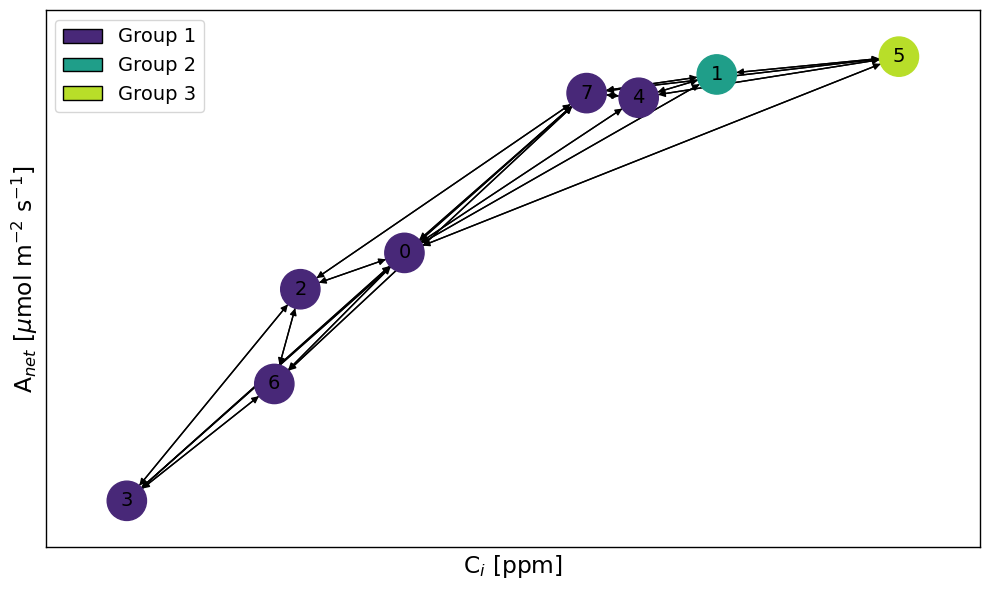

tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5,
         5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7],
        [1, 2, 3, 4, 5, 6, 7, 0, 4, 5, 7, 0, 3, 6, 7, 0, 2, 6, 7, 0, 1, 5, 7, 0,
         1, 4, 7, 0, 2, 3, 7, 0, 1, 2, 3, 4, 5, 6]])


In [18]:
plot_graph(graphs_train[123])
print(graphs_train[123].edge_index)

# **Spilling and regularisation of the dataset**

In [19]:
# =========================================================
# Regularization/normalization on graphs
# =========================================================
def fit_node_standardizer(graphs, eps=1e-8):
    X = torch.cat([g.x for g in graphs], dim=0).float()
    mean = X.mean(dim=0)
    std = X.std(dim=0)
    std = torch.clamp(std, min=eps)
    return mean, std

def apply_node_standardizer(graphs, mean, std):
    out = []
    for g in graphs:
        gg = g.clone()
        gg.x = (gg.x.float() - mean) / std
        out.append(gg)
    return out

# =========================================================
# Edge_attr standardization
# =========================================================
def fit_edge_standardizer(graphs, eps=1e-8):
    E = torch.cat([g.edge_attr for g in graphs if hasattr(g, "edge_attr") and g.edge_attr is not None], dim=0).float()
    mean = E.mean(dim=0)
    std = E.std(dim=0)
    std = torch.clamp(std, min=eps)
    return mean, std

def apply_edge_standardizer(graphs, mean, std):
    out = []
    for g in graphs:
        gg = g.clone()
        if hasattr(gg, "edge_attr") and gg.edge_attr is not None:
            gg.edge_attr = (gg.edge_attr.float() - mean) / std
        out.append(gg)
    return out

# =========================================================
# Split graphs (outside training)
# =========================================================
def split_graphs(graphs, train_frac=0.75, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(graphs))
    rng.shuffle(idx)
    ntr = int(np.floor(train_frac * len(idx)))
    train_graphs = [graphs[i] for i in idx[:ntr]]
    test_graphs  = [graphs[i] for i in idx[ntr:]]
    return train_graphs, test_graphs

In [20]:
# (A) split
train_graphs, test_graphs = split_graphs(graphs_train, train_frac=0.75, seed=42)

# (B) fit scalers on train only + apply to both (regularization/normalization)
x_mean, x_std = fit_node_standardizer(train_graphs)
train_graphs = apply_node_standardizer(train_graphs, x_mean, x_std)
test_graphs  = apply_node_standardizer(test_graphs,  x_mean, x_std)

# (C) edge_attr standardization (optional, but recommended)
e_mean, e_std = fit_edge_standardizer(train_graphs)
train_graphs = apply_edge_standardizer(train_graphs, e_mean, e_std)
test_graphs  = apply_edge_standardizer(test_graphs,  e_mean, e_std)

# **Train the model**

In [21]:
# =========================================================
# DataLoaders (outside training)
# =========================================================
def make_loaders(train_graphs, test_graphs, batch_size=128):
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_graphs,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


# # =========================================================
# # GAT model with edge_attr support
# # =========================================================
# class EdgeGAT(nn.Module):
#     def __init__(
#         self,
#         in_dim,
#         n_classes=3,
#         heads=4,
#         dropout=0.2,
#         num_layers=2,
#         hidden_sizes=None,
#         edge_dim=None,
#     ):
#         super().__init__()

#         self.dropout = dropout
#         self.heads = heads
#         self.num_layers = len(hidden_sizes)
#         self.edge_dim = edge_dim

#         self.convs = nn.ModuleList()
#         self.bns = nn.ModuleList()

#         prev_dim = in_dim
#         for hdim in hidden_sizes:
#             conv = GATConv(
#                 in_channels=prev_dim,
#                 out_channels=hdim,
#                 heads=heads,
#                 concat=True,
#                 dropout=dropout,
#                 edge_dim=edge_dim,
#             )
#             self.convs.append(conv)
#             self.bns.append(BatchNorm(hdim * heads))
#             prev_dim = hdim * heads

#         self.mlp = nn.Linear(prev_dim, n_classes)

#     def forward(self, x, edge_index, edge_attr=None):
#         for conv, bn in zip(self.convs, self.bns):
#             x = conv(x, edge_index, edge_attr=edge_attr)
#             x = bn(x)
#             x = torch.tanh(x)
#             x = F.dropout(x, p=self.dropout, training=self.training)

#         return self.mlp(x)

class EdgeGAT(nn.Module):
    def __init__(
        self,
        in_dim,
        n_classes=3,
        heads=4,
        dropout=0.2,
        hidden_sizes=None,
        edge_dim=None,
    ):
        super().__init__()

        self.dropout = dropout
        self.heads = heads
        self.num_layers = len(hidden_sizes)
        self.edge_dim = edge_dim

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        prev_dim = in_dim
        for i, hdim in enumerate(hidden_sizes):
            is_last = (i == len(hidden_sizes) - 1)

            conv = GATConv(
                in_channels=prev_dim,
                out_channels=hdim,
                heads=heads,
                concat=not is_last,   # last layer -> mean over heads
                dropout=dropout,
                edge_dim=edge_dim,
            )
            self.convs.append(conv)

            out_dim = hdim if is_last else hdim * heads
            self.bns.append(BatchNorm(out_dim))
            prev_dim = out_dim

        self.mlp = nn.Linear(prev_dim, n_classes)

    def forward(self, x, edge_index, edge_attr=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_attr=edge_attr)
            x = bn(x)
            x = torch.tanh(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        return self.mlp(x)


# =========================================================
# Eval
# =========================================================
@torch.no_grad()
def eval_loader(model, loader, device, class_weights=None, gamma = 2.0):
    model.eval()
    total_loss, total_correct, total_nodes = 0.0, 0, 0

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch.x, batch.edge_index, edge_attr=batch.edge_attr)

        # loss = F.cross_entropy(logits, batch.y, weight=class_weights)
        loss = focal_loss_multiclass(logits,batch.y,class_weights=class_weights,
                gamma=gamma,reduction="mean")
        pred = logits.argmax(dim=1)

        total_loss += float(loss.item()) * batch.y.numel()
        total_correct += int((pred == batch.y).sum().item())
        total_nodes += int(batch.y.numel())

    return total_loss / max(total_nodes, 1), total_correct / max(total_nodes, 1)


def evaluate_loader_metrics(model, loader, device, class_weights=None, gamma = 2.0):
    model.eval()

    all_y_true = []
    all_y_pred = []
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            logits = model(batch.x, batch.edge_index, edge_attr=batch.edge_attr)

            # loss = F.cross_entropy(logits, batch.y, weight=class_weights, reduction="sum")
            loss = focal_loss_multiclass(logits,batch.y,class_weights=class_weights,
                gamma=gamma,reduction="mean")
            preds = logits.argmax(dim=1)

            total_loss += loss.item()
            total_n += batch.y.numel()

            all_y_true.append(batch.y.cpu().numpy())
            all_y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    avg_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]

    fpr_list = []
    fnr_list = []

    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        fnr_i = FN / (FN + TP) if (FN + TP) > 0 else 0.0

        fpr_list.append(fpr_i)
        fnr_list.append(fnr_i)

    fpr = float(np.mean(fpr_list))
    fnr = float(np.mean(fnr_list))

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "fpr": fpr,
        "fnr": fnr,
        "f1": f1,
    }

    return metrics

# **Class Weight Calculation**

In [22]:
# =========================================================
# Inverse-frequency class weights from training graphs only
# =========================================================
def compute_inverse_frequency_class_weights(train_graphs, n_classes):
    y_all = torch.cat([g.y.view(-1).cpu() for g in train_graphs], dim=0)

    counts = torch.bincount(y_all, minlength=n_classes).float()

    # inverse frequency
    class_weights = 1.0 / counts.clamp(min=1.0)

    # optional but recommended: normalize so mean weight = 1
    class_weights = class_weights / class_weights.mean()

    return class_weights, counts

# =========================================================
# Weighted focal loss for multiclass classification
# =========================================================
def focal_loss_multiclass(logits, targets, class_weights=None, gamma=2.0, reduction="mean"):
    """
    logits:  [N, C]
    targets: [N]   integer class labels
    class_weights: [C] or None
    gamma: focusing parameter
    """
    ce = F.cross_entropy(
        logits,
        targets,
        weight=class_weights,
        reduction="none"
    )  # [N]

    pt = torch.exp(-ce)   # pt = predicted prob of true class (effective form)
    loss = ((1 - pt) ** gamma) * ce

    if reduction == "mean":
        return loss.mean()
    elif reduction == "sum":
        return loss.sum()
    else:
        return loss

In [23]:
# =========================================================
# Train
# =========================================================
def train_only(
    model,
    train_loader,
    test_loader,
    epochs=100,
    lr=1e-3,
    wd=1e-4,
    seed=42,
    gamma = 2.0,
    class_weights=None
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if class_weights is not None:
        class_weights = class_weights.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()

        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()

            logits = model(batch.x, batch.edge_index, edge_attr=batch.edge_attr)

            # loss = F.cross_entropy(logits, batch.y, weight=class_weights)
            loss = focal_loss_multiclass(logits,batch.y,class_weights=class_weights,
                gamma=gamma,reduction="mean")

            loss.backward()
            opt.step()

        train_metrics = evaluate_loader_metrics(model, train_loader, device, class_weights=class_weights, gamma = gamma)
        test_metrics  = evaluate_loader_metrics(model, test_loader,  device, class_weights=class_weights, gamma = gamma)

        if test_metrics["accuracy"] > best_acc:
            best_acc = test_metrics["accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if ep == 1 or ep % 200 == 0 or ep == epochs:
            print(
                f"\nEpoch {ep:4d} "
                f"TRAIN_Loss : {train_metrics['loss']:.3f} "
                f"TRAIN_Accuracy : {train_metrics['accuracy']:.3f} "
                f"TEST_Loss : {test_metrics['loss']:.3f} "
                f"TEST_Accuracy : {test_metrics['accuracy']:.3f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    final_train_metrics = evaluate_loader_metrics(model, train_loader, device, class_weights=class_weights, gamma = gamma)
    final_test_metrics  = evaluate_loader_metrics(model, test_loader,  device, class_weights=class_weights, gamma = gamma)

    print("\n" + "=" * 60)
    print("FINAL METRICS USING BEST MODEL")
    print("=" * 60)

    print("TRAIN")
    print(f"  Accuracy  : {final_train_metrics['accuracy']:.4f}")
    print(f"  Precision : {final_train_metrics['precision']:.4f}")
    print(f"  Recall    : {final_train_metrics['recall']:.4f}")
    print(f"  FPR       : {final_train_metrics['fpr']:.4f}")
    print(f"  FNR       : {final_train_metrics['fnr']:.4f}")
    print(f"  F1        : {final_train_metrics['f1']:.4f}")

    print("TEST")
    print(f"  Accuracy  : {final_test_metrics['accuracy']:.4f}")
    print(f"  Precision : {final_test_metrics['precision']:.4f}")
    print(f"  Recall    : {final_test_metrics['recall']:.4f}")
    print(f"  FPR       : {final_test_metrics['fpr']:.4f}")
    print(f"  FNR       : {final_test_metrics['fnr']:.4f}")
    print(f"  F1        : {final_test_metrics['f1']:.4f}")

    return model, final_train_metrics, final_test_metrics

In [24]:
# =========================================================
# Compute class weights from training data
# =========================================================
NCLASS = 3   # or use your existing NCLASS variable
class_weights, class_counts = compute_inverse_frequency_class_weights(
    train_graphs=train_graphs,
    n_classes=NCLASS
)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())

Class counts: [36721.0, 16990.0, 19853.0]
Class weights: [0.5986858606338501, 1.2939579486846924, 1.107356309890747]


# **Save multiple models**

In [25]:
# =========================================================
# Make loaders
# =========================================================
train_loader, test_loader = make_loaders(train_graphs=train_graphs,
    test_graphs=test_graphs,batch_size=128)

# =========================================================
# Save model + training parameters + standardization variables
# =========================================================
MODEL_DIR = os.path.join(BASE_PATH, "GAT_FC_GNN_Focal")
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
np.concatenate((np.arange(0,1.5,0.4),np.array([3.0])))

array([0. , 0.4, 0.8, 1.2, 3. ])

In [28]:
# =========================================================
# Make parameters
# =========================================================
IN_DIM   = train_graphs[0].x.shape[1]
HIDDEN_SIZES = [64, 64]
NLAYERS  = 2
NCLASS   = 3
EPOCH    = 800
LR       = 1e-3
WD       = 1e-4
BATCH_SIZE = 128
HEADS = 5
EDGE_DIM = 2
GAMMA = [0.0, 0.5] # np.concatenate((np.arange(0,1.5,0.4),np.array([1.5, 2.0, 2.5, 3.0]))) #

for m_num in range(4,31):

    for gamma in GAMMA:

        run_seed = int(42 + m_num)

        # =========================================================
        # Make loaders
        # =========================================================
        train_loader, test_loader = make_loaders(train_graphs=train_graphs,
            test_graphs=test_graphs,batch_size=BATCH_SIZE)


        # =========================================================
        # Build model
        # =========================================================
        model = EdgeGAT(
                in_dim=IN_DIM,
                n_classes=NCLASS,
                heads=HEADS,
                dropout=0.2,
                hidden_sizes=HIDDEN_SIZES,
                edge_dim=EDGE_DIM
            )

        # =========================================================
        # Train
        # =========================================================
        model, final_train_metrics, final_test_metrics = train_only(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=EPOCH,lr=LR,
            wd=WD,seed=run_seed,
            class_weights=class_weights,
            gamma = gamma)

        torch.save({
            "model_state_dict": model.state_dict(),

            # model/training parameters
            "IN_DIM": IN_DIM,
            "NLAYERS": NLAYERS,
            "HIDDEN_SIZES": HIDDEN_SIZES,
            "NCLASS": NCLASS,
            "EPOCH": EPOCH,
            "LR": LR,
            "WD": WD,
            "HEADS": HEADS,
            "EDGE_DIM": EDGE_DIM,
            "GAMMA": gamma,

            # standardization variables
            "x_mean": x_mean,
            "x_std": x_std,
            "e_mean": e_mean,
            "e_std": e_std,

            "seed": run_seed,

            # final metrics
            "final_train_metrics": final_train_metrics,
            "final_test_metrics": final_test_metrics,
        }, MODEL_DIR + f"/EdgeGAT_checkpoint_G0_{int(gamma*10)}_model_{m_num}.pt")


Epoch    1 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.763 TEST_Loss : 0.000 TEST_Accuracy : 0.766

Epoch  200 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.876 TEST_Loss : 0.000 TEST_Accuracy : 0.873

Epoch  400 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.879 TEST_Loss : 0.000 TEST_Accuracy : 0.875

Epoch  600 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.889 TEST_Loss : 0.000 TEST_Accuracy : 0.881

Epoch  800 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.885 TEST_Loss : 0.000 TEST_Accuracy : 0.877

FINAL METRICS USING BEST MODEL
TRAIN
  Accuracy  : 0.8898
  Precision : 0.8625
  Recall    : 0.8703
  FPR       : 0.0511
  FNR       : 0.1297
  F1        : 0.8661
TEST
  Accuracy  : 0.8827
  Precision : 0.8534
  Recall    : 0.8617
  FPR       : 0.0544
  FNR       : 0.1383
  F1        : 0.8571

Epoch    1 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.751 TEST_Loss : 0.000 TEST_Accuracy : 0.757

Epoch  200 TRAIN_Loss : 0.000 TRAIN_Accuracy : 0.874 TEST_Loss : 0.000 TEST_Accuracy : 0.869

Epoch  400 TRAIN_Loss : 0.000 TRAIN_Accuracy :

# **Testing on unseen data**

In [ ]:
# =========================================================
# Load one saved GAT ensemble checkpoint
# =========================================================
def load_saved_edgegat_checkpoint(m_num, model_dir=MODEL_DIR, gamma = None, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ckpt_file = os.path.join(model_dir, f"EdgeGAT_checkpoint_G0_{int(gamma*10)}.pt")

    if not os.path.exists(ckpt_file):
        return None

    checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)

    model = EdgeGAT(
        in_dim=checkpoint["IN_DIM"],
        hidden_sizes=checkpoint["HIDDEN_SIZES"],
        n_classes=checkpoint["NCLASS"],
        heads=checkpoint["HEADS"],
        dropout=checkpoint.get("DROPOUT", 0.2),
        edge_dim=checkpoint.get("EDGE_DIM", 2),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return {
        "checkpoint": checkpoint,
        "model": model,
        "x_mean": checkpoint["x_mean"],
        "x_std": checkpoint["x_std"],
        "e_mean": checkpoint.get("e_mean", None),
        "e_std": checkpoint.get("e_std", None),
        "file": ckpt_file
    }

In [ ]:
# =========================================================
# Evaluate loader and also return nodewise predictions
# =========================================================
@torch.no_grad()
def evaluate_loader_metrics_with_predictions_gat(model, loader, device, gamma = 2.0, class_weights=None):
    model.eval()

    all_y_true = []
    all_y_pred = []
    total_loss = 0.0
    total_n = 0

    pred_rows = []
    graph_offset = 0

    for batch in loader:
        batch = batch.to(device)

        # ----------------------------------------------
        # IMPORTANT:
        # if your model forward is different, update here
        # ----------------------------------------------
        logits = model(batch.x, batch.edge_index, batch.edge_attr)

        # loss = F.cross_entropy(logits, batch.y, weight=class_weights, reduction="sum")
        loss = focal_loss_multiclass(logits,batch.y,class_weights=class_weights,
                gamma=gamma,reduction="mean")
        preds = logits.argmax(dim=1)

        total_loss += loss.item()
        total_n += batch.y.numel()

        y_true_np = batch.y.cpu().numpy()
        y_pred_np = preds.cpu().numpy()
        batch_graph_ids = batch.batch.cpu().numpy()

        all_y_true.append(y_true_np)
        all_y_pred.append(y_pred_np)

        local_node_counter = {}

        for i in range(len(y_true_np)):
            g_local = int(batch_graph_ids[i])
            g_global = graph_offset + g_local

            if g_local not in local_node_counter:
                local_node_counter[g_local] = 0

            node_in_graph = local_node_counter[g_local]
            local_node_counter[g_local] += 1

            pred_rows.append({
                "graph_idx": g_global,
                "node_idx": node_in_graph,
                "true_zero": int(y_true_np[i]),
                "pred_zero": int(y_pred_np[i]),
                "true_label": int(y_true_np[i]) + 1,
                "pred_label": int(y_pred_np[i]) + 1,
            })

        graph_offset += int(batch.num_graphs)

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    avg_loss = total_loss / max(total_n, 1)
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]

    fpr_list = []
    fnr_list = []

    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        fnr_i = FN / (FN + TP) if (FN + TP) > 0 else 0.0

        fpr_list.append(fpr_i)
        fnr_list.append(fnr_i)

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": float(np.mean(fpr_list)),
        "fnr": float(np.mean(fnr_list)),
    }

    pred_df = pd.DataFrame(pred_rows)
    return metrics, pred_df

In [ ]:
# =========================================================
# Evaluate all saved GAT ensemble models on unseen graphs_test
# Reuses:
#   - EdgeGAT
#   - apply_node_standardizer(...)
#   - apply_edge_standardizer(...)
#   - DataLoader
# =========================================================
def evaluate_saved_edgegat_ensemble_on_unseen_graphs(
    graphs_unseen,
    model_dir=MODEL_DIR,
    ensemble_size=30,
    batch_size=128,
    GAMMA = None,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_rows = []
    all_predictions = {}

    for m_num in range(1, ensemble_size + 1):
        print(f"\n===== Evaluating EdgeGAT ensemble model {m_num} on unseen graphs =====")

        gamma = GAMMA[m_num-1]
        print(gamma)
        bundle = load_saved_edgegat_checkpoint(
            m_num=m_num,
            model_dir=model_dir,
            device=device,
            gamma = gamma
        )

        if bundle is None:
            print(f"Skipping missing checkpoint for model {m_num}")
            continue

        if not torch.is_tensor(bundle["x_mean"]):
            x_mean = torch.tensor(bundle["x_mean"], dtype=torch.float32)
            e_mean = torch.tensor(bundle["e_mean"], dtype=torch.float32)
        else:
            x_mean = bundle["x_mean"].float()
            e_mean = bundle["e_mean"].float()

        if not torch.is_tensor(bundle["x_std"]):
            x_std = torch.tensor(bundle["x_std"], dtype=torch.float32)
            e_std = torch.tensor(bundle["e_std"], dtype=torch.float32)
        else:
            x_std = bundle["x_std"].float()
            e_std = bundle["e_std"].float()

        # move scaler stats to same device as graph x
        data_device = graphs_unseen[0].x.device
        x_mean_here = x_mean.to(data_device)
        x_std_here = x_std.to(data_device)
        e_mean_here = e_mean.to(data_device)
        e_std_here = e_std.to(data_device)

        # standardize unseen nodes with the scaler saved for this model
        graphs_unseen_sc = apply_node_standardizer(
            graphs_unseen,x_mean_here,x_std_here)

        # standardize unseen edges with the scaler saved for this model
        graphs_unseen_sc = apply_edge_standardizer(
            graphs_unseen_sc,e_mean_here,e_std_here)

        unseen_loader = DataLoader(graphs_unseen_sc, batch_size=batch_size, shuffle=False)

        metrics, pred_df = evaluate_loader_metrics_with_predictions_gat(
            model=bundle["model"],
            loader=unseen_loader,
            device=device,
            class_weights=None,
            gamma = gamma
        )

        row = {
            "m_num": m_num,
            "n_graphs_unseen": len(graphs_unseen),
            "n_nodes_total": int(sum(g.y.numel() for g in graphs_unseen)),
            "test_loss": metrics["loss"],
            "test_accuracy": metrics["accuracy"],
            "test_precision": metrics["precision"],
            "test_recall": metrics["recall"],
            "test_f1": metrics["f1"],
            "test_fpr": metrics["fpr"],
            "test_fnr": metrics["fnr"],
            "seed": bundle["checkpoint"].get("seed", np.nan),
            "gamma": gamma,
        }
        all_rows.append(row)

        pred_df["m_num"] = m_num
        all_predictions[m_num] = pred_df

    results_df = pd.DataFrame(all_rows)

    if len(results_df) == 0:
        raise ValueError("No saved EdgeGAT checkpoints were found / evaluated.")

    summary_df = pd.DataFrame([{
        "accuracy_mean": results_df["test_accuracy"].mean(),
        "accuracy_std": results_df["test_accuracy"].std(),
        "precision_mean": results_df["test_precision"].mean(),
        "precision_std": results_df["test_precision"].std(),
        "recall_mean": results_df["test_recall"].mean(),
        "recall_std": results_df["test_recall"].std(),
        "f1_mean": results_df["test_f1"].mean(),
        "f1_std": results_df["test_f1"].std(),
        "fpr_mean": results_df["test_fpr"].mean(),
        "fpr_std": results_df["test_fpr"].std(),
        "fnr_mean": results_df["test_fnr"].mean(),
        "fnr_std": results_df["test_fnr"].std(),
        "gamma": results_df["gamma"].mean(),
    }])

    return results_df, summary_df, all_predictions

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GAMMA = np.concatenate((np.arange(0,1.5,0.4),np.array([0.5, 1, 1.5, 2.0, 2.5, 3.0])))

edgegat_unseen_results_df, edgegat_unseen_summary_df, edgegat_unseen_predictions = (
    evaluate_saved_edgegat_ensemble_on_unseen_graphs(
        graphs_unseen=graphs_test,
        model_dir=MODEL_DIR,
        ensemble_size=len(GAMMA),
        batch_size=128,
        GAMMA = GAMMA,
        device=device
    )
)

print("\n===== Per-model results on unseen graphs =====")
print(edgegat_unseen_results_df)

print("\n===== Summary across 30 GAT models =====")
print(edgegat_unseen_summary_df)


===== Evaluating EdgeGAT ensemble model 1 on unseen graphs =====
0.0

===== Evaluating EdgeGAT ensemble model 2 on unseen graphs =====
0.4

===== Evaluating EdgeGAT ensemble model 3 on unseen graphs =====
0.8

===== Evaluating EdgeGAT ensemble model 4 on unseen graphs =====
1.2000000000000002

===== Evaluating EdgeGAT ensemble model 5 on unseen graphs =====
0.5

===== Evaluating EdgeGAT ensemble model 6 on unseen graphs =====
1.0

===== Evaluating EdgeGAT ensemble model 7 on unseen graphs =====
1.5

===== Evaluating EdgeGAT ensemble model 8 on unseen graphs =====
2.0

===== Evaluating EdgeGAT ensemble model 9 on unseen graphs =====
2.5

===== Evaluating EdgeGAT ensemble model 10 on unseen graphs =====
3.0

===== Per-model results on unseen graphs =====
   m_num  n_graphs_unseen  n_nodes_total  test_loss  test_accuracy  \
0      1             2117          24528   0.000193       0.885192   
1      2             2117          24528   0.000152       0.882787   
2      3             2117 

In [ ]:
edgegat_unseen_excel_file = os.path.join(MODEL_DIR, "edgegat_unseen_test_results.xlsx")

with pd.ExcelWriter(edgegat_unseen_excel_file, engine="openpyxl") as writer:
    edgegat_unseen_results_df.to_excel(writer, sheet_name="per_model_results", index=False)


print(f"Saved unseen graph evaluation to: {edgegat_unseen_excel_file}")

Saved unseen graph evaluation to: /content/drive/My Drive/Colab Notebooks/Seg_Curves/GAT_FC_GNN_Focal/edgegat_unseen_test_results.xlsx


In [ ]:
# # =========================================================
# # Load model + parameters + standardization variables
# # =========================================================
# checkpoint = torch.load(MODEL_DIR + "/" +"EdgeGCN_checkpoint_1.pt", map_location="cpu")

# print(checkpoint)

# IN_DIM = checkpoint["IN_DIM"]
# HIDDEN = checkpoint["HIDDEN"]
# NCLASS = checkpoint["NCLASS"]
# EPOCH  = checkpoint["EPOCH"]
# LR     = checkpoint["LR"]
# WD     = checkpoint["WD"]

# x_mean = checkpoint["x_mean"]
# x_std  = checkpoint["x_std"]

# final_train_metrics = checkpoint["final_train_metrics"]
# final_test_metrics  = checkpoint["final_test_metrics"]

# loaded_model = EdgeGCN(in_dim=IN_DIM,
#      hidden=HIDDEN,
#      n_classes=NCLASS,
#      num_layers=NLAYERS,
#      dropout=0.2)

# loaded_model.load_state_dict(checkpoint["model_state_dict"])
# loaded_model.eval()

{'model_state_dict': OrderedDict({'convs.0.bias': tensor([-1.9178e-03, -6.7607e-03,  8.7879e-03, -3.7872e-02,  3.9794e-02,
         1.2388e-03, -1.4856e-02, -6.6247e-03, -1.8962e-02, -2.5578e-03,
        -2.1245e-01,  1.0316e-02, -8.7368e-04, -1.1045e-04, -8.1463e-03,
        -2.0538e-03, -1.8159e-02,  5.6312e-03, -5.3752e-03,  7.2736e-03,
         4.9134e-02,  3.5466e-03, -1.1710e-02, -8.4919e-03, -4.9399e-03,
        -1.8392e-02, -3.6161e-03,  1.6812e-02,  1.8420e-02, -3.6520e-04,
        -4.7382e-03,  1.9567e-03, -1.1875e-04,  1.1936e-03, -1.3595e-03,
        -9.7018e-03, -5.1925e-03,  1.1723e-02,  9.5515e-01,  7.1627e-03,
         5.0363e-03, -3.2020e-01, -3.7619e-03, -2.2733e-03,  1.4304e-02,
         2.0110e-02,  1.0783e-02,  7.0740e-04,  1.6156e-04, -1.5684e-02,
         1.1154e-03, -3.9218e-02,  9.2877e-01,  2.0428e-03, -8.0355e-04,
        -4.5271e-02, -2.7812e-02, -5.8849e-02,  5.4008e-01, -1.5977e-02,
         7.7163e-02, -4.5484e-03, -4.5775e-01, -1.1372e+00,  1.3884e+00,
 

EdgeGCN(
  (convs): ModuleList(
    (0): GCNConv(4, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp): Linear(in_features=128, out_features=3, bias=True)
)

# Standardize the unseen graph #

In [ ]:
# =========================================================
# Use loaded standardization variables on new graphs
# =========================================================
graphs_test = apply_node_standardizer(graphs_test, x_mean, x_std)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graphs_loader = DataLoader(graphs_test, batch_size=128, shuffle=False)
loaded_model = loaded_model.to(device)

metrics = evaluate_loader_metrics(loaded_model, graphs_loader, device, class_weights=None)

print(pd.Series(metrics))

loss         3.220687
accuracy     0.504770
precision    0.168257
recall       0.333333
fpr          0.333333
fnr          0.666667
f1           0.223631
dtype: float64
